1. 환경 설정 및 라이브러리 설치
2. 사전 학습된 SSD 모델 로드
3. 테스트 이미지 준비
4. Object Detection 실행
5. 결과 시각화
6. 웹캠/동영상 실시간 탐지 (보너스)


In [1]:
# 1-1. 필수 라이브러리 import
import torch
import torchvision
from torchvision.models.detection import ssd300_vgg16, SSD300_VGG16_Weights
from torchvision.transforms import functional as F
from torchvision.utils import draw_bounding_boxes
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO


# 한글 폰트 설정 (matplotlib 한글 깨짐 방지)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False


print("="*50)
print("="*50)
print(f"PyTorch 버전: {torch.__version__}")
print(f"TorchVision 버전: {torchvision.__version__}")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 디바이스: {device}")


PyTorch 버전: 2.10.0+cu130
TorchVision 버전: 0.25.0+cu130
CUDA 사용 가능: True
사용 디바이스: cuda


In [2]:
"""
사전 학습된 SSD300 모델 로드
- COCO 데이터셋으로 학습됨 (80개 클래스)
- 입력 크기: 300x300
"""
# 최신 가중치 사용 (2025년 1월 기준)
weights = SSD300_VGG16_Weights.DEFAULT
model = ssd300_vgg16(weights=weights)


# 모델을 평가 모드로 설정 (중요!)
model.eval()
model = model.to(device)




print(f"모델 타입: {type(model).__name__}")


# COCO 데이터셋 클래스 이름 가져오기
class_names = weights.meta["categories"]
print(f"\n탐지 가능한 클래스 수: {len(class_names)}개")
print(f"클래스 예시: {class_names[:10]}")


Downloading: "https://download.pytorch.org/models/ssd300_vgg16_coco-b556d3b4.pth" to /home/kim/.cache/torch/hub/checkpoints/ssd300_vgg16_coco-b556d3b4.pth


100%|██████████| 136M/136M [00:02<00:00, 56.6MB/s] 


모델 타입: SSD

탐지 가능한 클래스 수: 91개
클래스 예시: ['__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat']


In [12]:
# 연습

temp_url = "https://images.unsplash.com/photo-1568605114967-8130f3a36994?w=800"
response = requests.get(temp_url)
response # 200은 성공했다는 뜻
a = Image.open(BytesIO(response.content)).convert('RGB')


In [14]:
np.array(a).shape

(533, 800, 3)

In [16]:
F.to_tensor(a).shape

torch.Size([3, 533, 800])

In [11]:
# 테스트 이미지 다운로드 전처리

def download_image(url):
    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).convert('RGB')
    return img

In [15]:
def preprocess_image(image):
    img_tensor = F.to_tensor(image)

    img_tensor = img_tensor.unsqueeze(0)

    original = image.copy()

    return img_tensor, original

In [17]:
test_image_urls = [
    "https://images.unsplash.com/photo-1568605114967-8130f3a36994?w=800",  # 사람들
    "https://images.unsplash.com/photo-1449965408869-eaa3f722e40d?w=800",  # 거리 풍경
    "https://images.unsplash.com/photo-1544568100-847a948585b9?w=800",   # 강아지
]

In [18]:
image_url = test_image_urls[1]

이미지 로드 완료함. (800, 533)
torch.Size([1, 3, 533, 800])


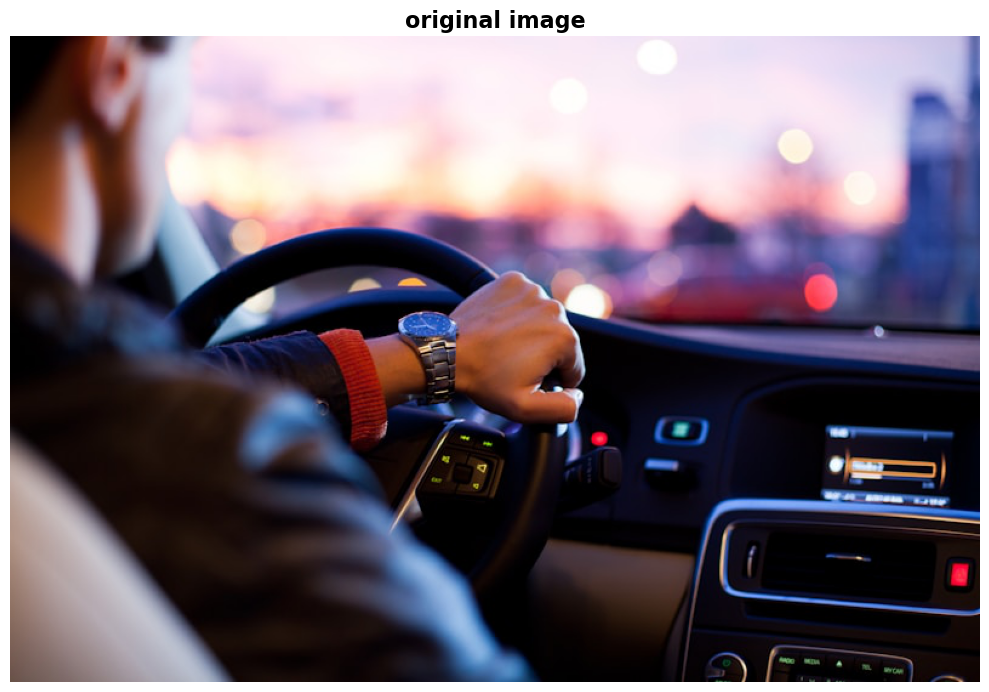

In [29]:
image = download_image(image_url)

if image is not None:
    print(f'이미지 로드 완료함. {image.size}')
    img_tensor, original_image = preprocess_image(image)
    print(img_tensor.shape)
    plt.figure(figsize=(10,10))
    plt.imshow(original)
    plt.title('original image',fontsize=16,fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [28]:
a = torch.tensor([0])
print(a.device)
a.to(device)
print(a.device)

cpu
cpu


In [26]:
# SSD 로 객체 탐지 수행

def detect_objects(model, image_tensor, confidence_threshold=0.5):
    image_tensor = image_tensor.to(device)
    
    with torch.no_grad():
        logits = model(image_tensor)
    
    pred = logits[0] # 첫번째 이미지 예측 결과

    keep_indices = (pred['scores'] > confidence_threshold)
    filtered_pred = {
        'boxes': pred['boxes'][keep_indices],   # [N, 4] (x1,y1,x2,y2)
        'labels': pred['labels'][keep_indices], # [N] 클래스 ID
        'scores': pred['scores'][keep_indices], # [N] 신뢰도 점수
    }

    num_detections = len(filtered_pred['boxes'])
    print(f'탐지된 객체 수 : {num_detections}')

    if num_detections > 0:
        for i in range(num_detections):
            label_id = filtered_pred['labels'][i].item()
            score = filtered_pred['scores'][i].item()
            class_name = class_names[label_id]
            print(f'{i+1}. {class_name:15s} | 신뢰도: {score:.2%}')
        print('-'*60)
    
    return filtered_pred

In [27]:
predictions = detect_objects(model, img_tensor, confidence_threshold=0.5)

탐지된 객체 수 : 1
1. person          | 신뢰도: 83.73%
------------------------------------------------------------


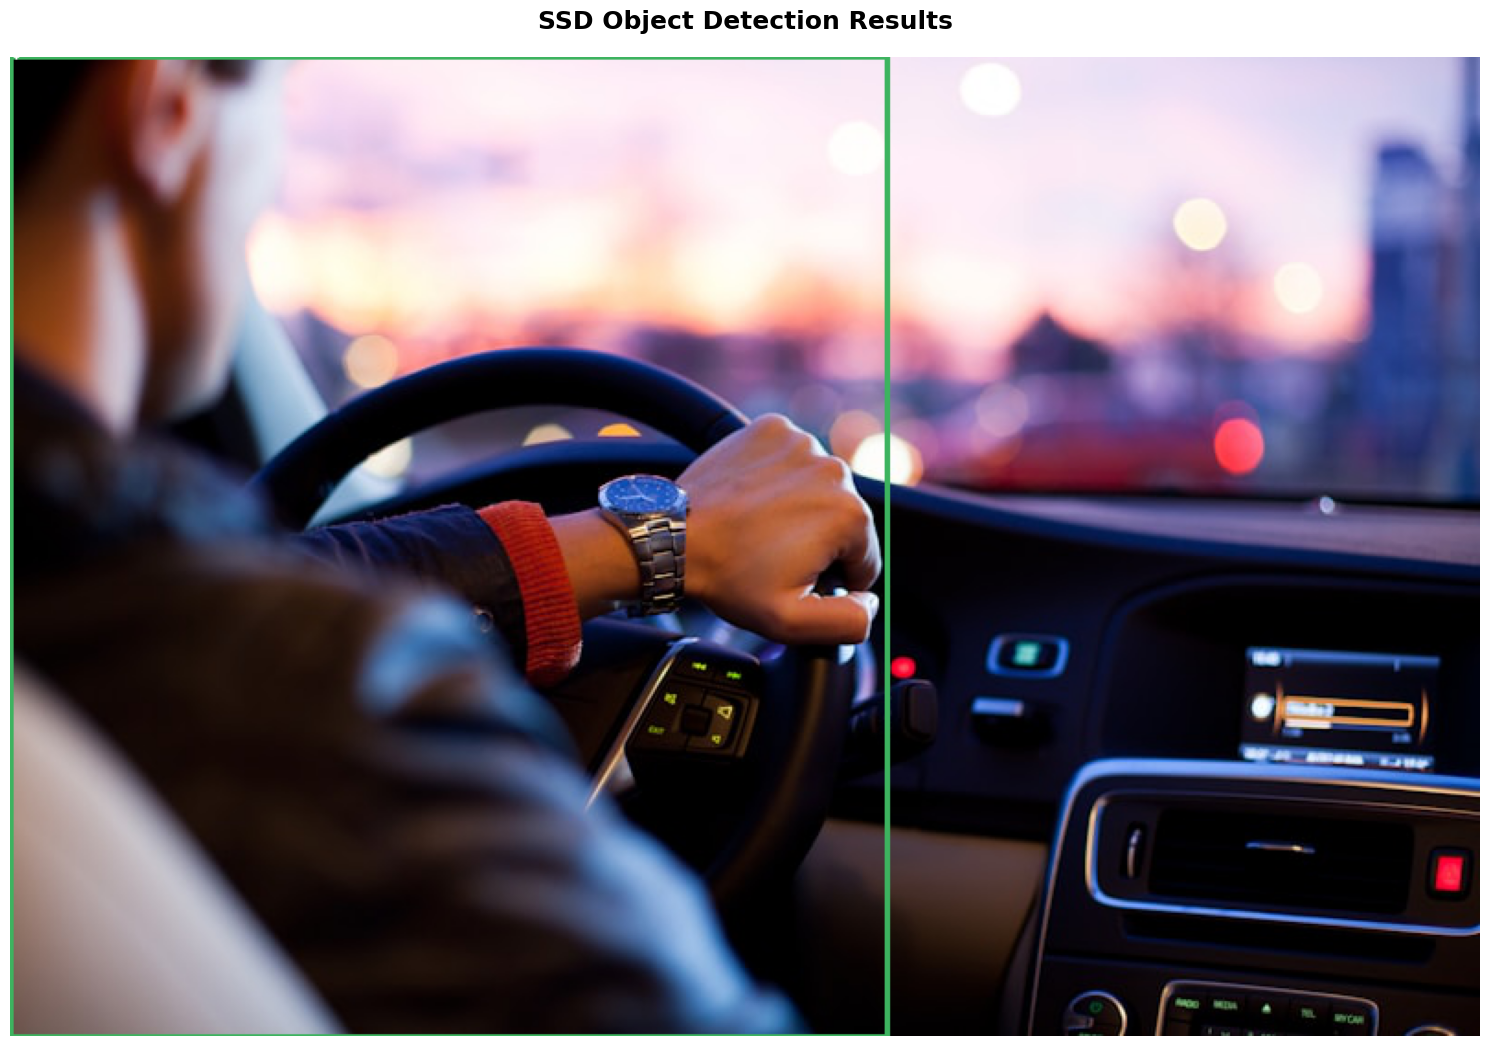

In [33]:
"""
탐지 결과를 이미지에 그리기
"""

def visualize_predictions(image, predictions, class_names,
                         font_scale=0.8, thickness=3):
    """
    탐지 결과 시각화

    Args:
        image: PIL Image (원본)
        predictions: 탐지 결과
        class_names: 클래스 이름 리스트
        font_scale: 텍스트 크기
        thickness: 박스 두께

    Returns:
        numpy array: 시각화된 이미지
    """
    # PIL Image를 numpy array로 변환
    img_np = np.array(image)
    img_cv = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

    boxes = predictions['boxes'].cpu().numpy()
    labels = predictions['labels'].cpu().numpy()
    scores = predictions['scores'].cpu().numpy()

    # 색상 팔레트 (클래스별 다른 색상)
    np.random.seed(42)
    colors = np.random.randint(0, 255, size=(len(class_names), 3), dtype=np.uint8)

    # 각 탐지 결과 그리기
    for box, label, score in zip(boxes, labels, scores):
        # 박스 좌표 (x1, y1, x2, y2)
        x1, y1, x2, y2 = box.astype(int)

        # 클래스 이름과 색상
        class_name = class_names[label]
        color = colors[label].tolist()

        # 박스 그리기
        cv2.rectangle(img_cv, (x1, y1), (x2, y2), color, thickness)

        # 레이블 텍스트
        text = f"{class_name}: {score:.2f}"

        # 텍스트 배경 (가독성 향상)
        (text_width, text_height), _ = cv2.getTextSize(
            text, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness
        )

        cv2.rectangle(
            img_cv,
            (x1, y1 - text_height - 10),
            (x1 + text_width, y1),
            color,
            -1  # 채우기
        )

        # 텍스트 그리기
        cv2.putText(
            img_cv,
            text,
            (x1, y1 - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            font_scale,
            (255, 255, 255),  # 흰색 텍스트
            thickness
        )

    # BGR을 RGB로 변환
    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)

    return img_rgb

# 시각화
result_image = visualize_predictions(
    original_image,
    predictions,
    class_names,
    font_scale=0.7,
    thickness=2
)

# 결과 출력
plt.figure(figsize=(15, 12))
plt.imshow(result_image)
plt.title("SSD Object Detection Results", fontsize=18, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()



테스트 1/3: https://images.unsplash.com/photo-1568605114967-8130f3a36994?w=800
탐지된 객체 수 : 0

테스트 2/3: https://images.unsplash.com/photo-1449965408869-eaa3f722e40d?w=800
탐지된 객체 수 : 1
1. person          | 신뢰도: 83.73%
------------------------------------------------------------

테스트 3/3: https://images.unsplash.com/photo-1544568100-847a948585b9?w=800
탐지된 객체 수 : 1
1. dog             | 신뢰도: 85.29%
------------------------------------------------------------


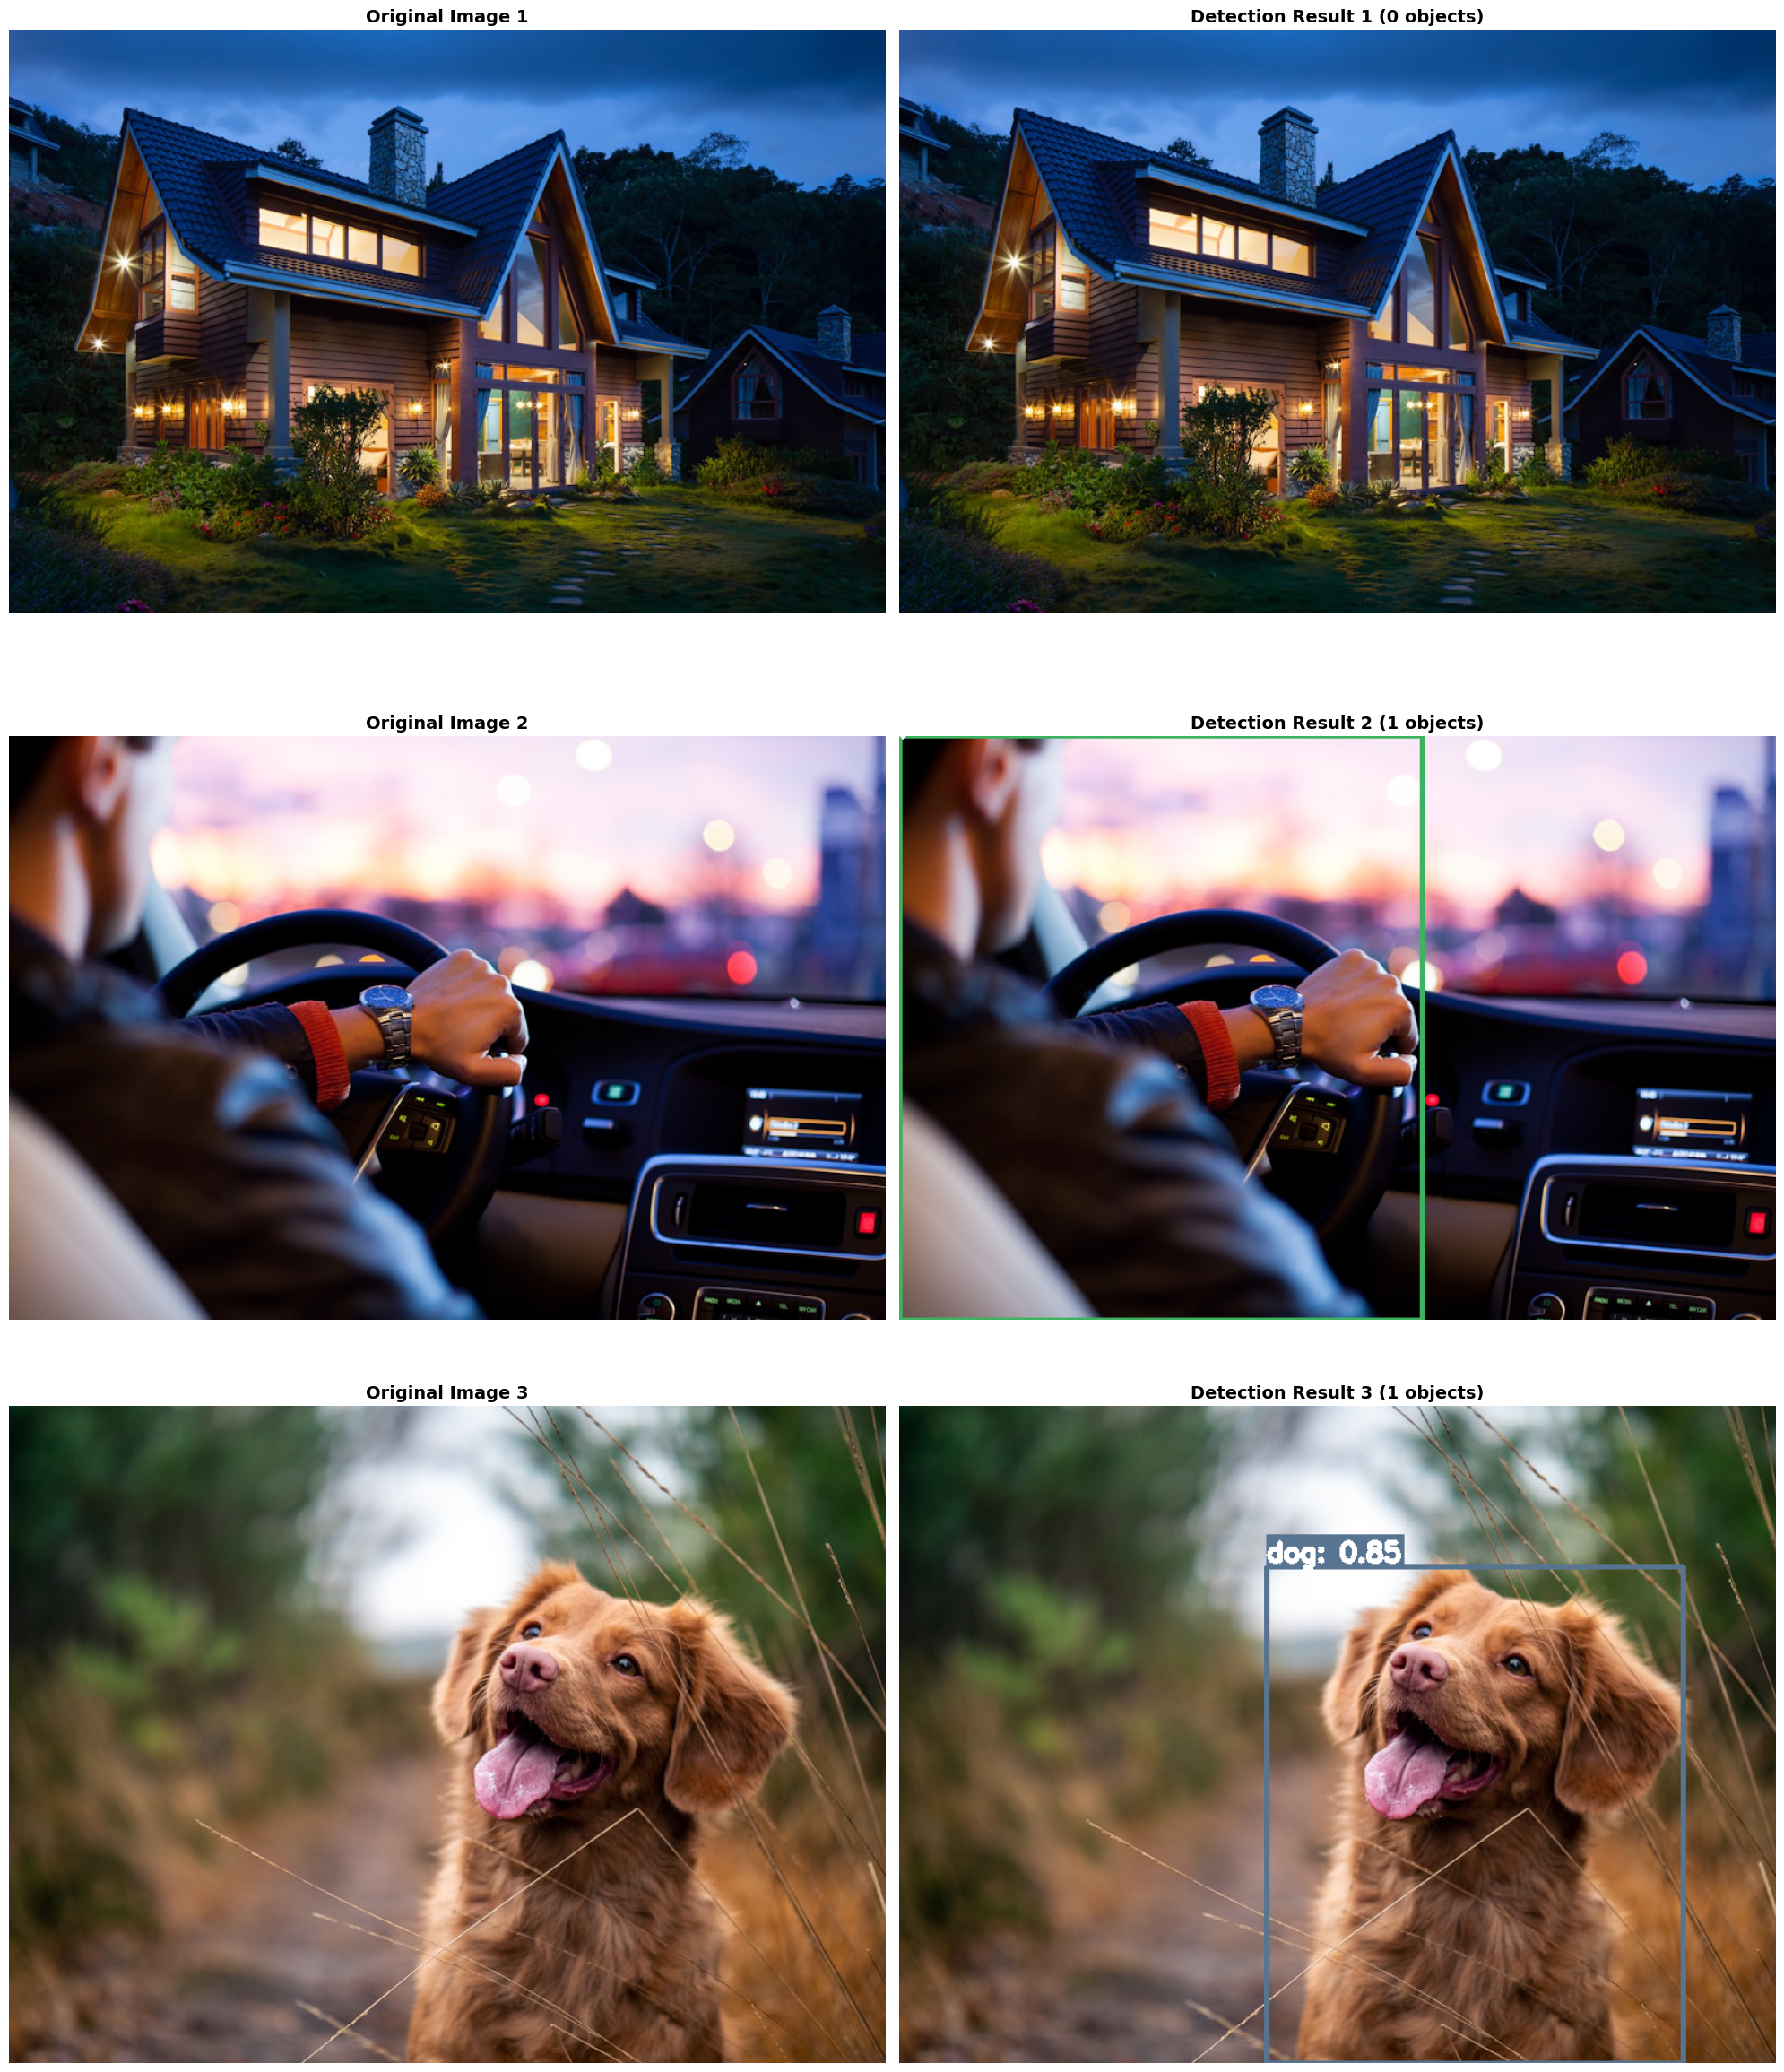

In [ ]:
def test_multiple_images(model, image_urls, class_names, confidence_threshold=0.5):
    """
    여러 이미지로 객체 탐지 테스트

    Args:
        model: SSD 모델
        image_urls: 이미지 URL 리스트
        class_names: 클래스 이름 리스트
        confidence_threshold: 신뢰도 임계값
    """
    num_images = len(image_urls)

    # 서브플롯 생성
    fig, axes = plt.subplots(num_images, 2, figsize=(20, 8*num_images))
    if num_images == 1:
        axes = axes.reshape(1, -1)

    for idx, url in enumerate(image_urls):
        print(f"\n{'='*60}")
        print(f"테스트 {idx+1}/{num_images}: {url}")
        print('='*60)

        # 이미지 다운로드
        image = download_image(url)
        if image is None:
            continue

        # 전처리
        img_tensor, original = preprocess_image(image)

        # 객체 탐지
        predictions = detect_objects(model, img_tensor, confidence_threshold)

        # 시각화
        result = visualize_predictions(original, predictions, class_names)

        # 원본과 결과 비교
        axes[idx, 0].imshow(original)
        axes[idx, 0].set_title(f"Original Image {idx+1}", fontsize=14, fontweight='bold')
        axes[idx, 0].axis('off')

        axes[idx, 1].imshow(result)
        axes[idx, 1].set_title(f"Detection Result {idx+1} ({len(predictions['boxes'])} objects)",
                               fontsize=14, fontweight='bold')
        axes[idx, 1].axis('off')

    plt.tight_layout()
    plt.show()


print("\n" + "="*60)

# 다양한 테스트 이미지
test_urls = [
    "https://images.unsplash.com/photo-1568605114967-8130f3a36994?w=800",  # 사람들
    "https://images.unsplash.com/photo-1449965408869-eaa3f722e40d?w=800",  # 거리
    "https://images.unsplash.com/photo-1544568100-847a948585b9?w=800",   # 강아지
]

# 테스트 실행
test_multiple_images(model, test_urls, class_names, confidence_threshold=0.5)


신뢰도 임계값 비교


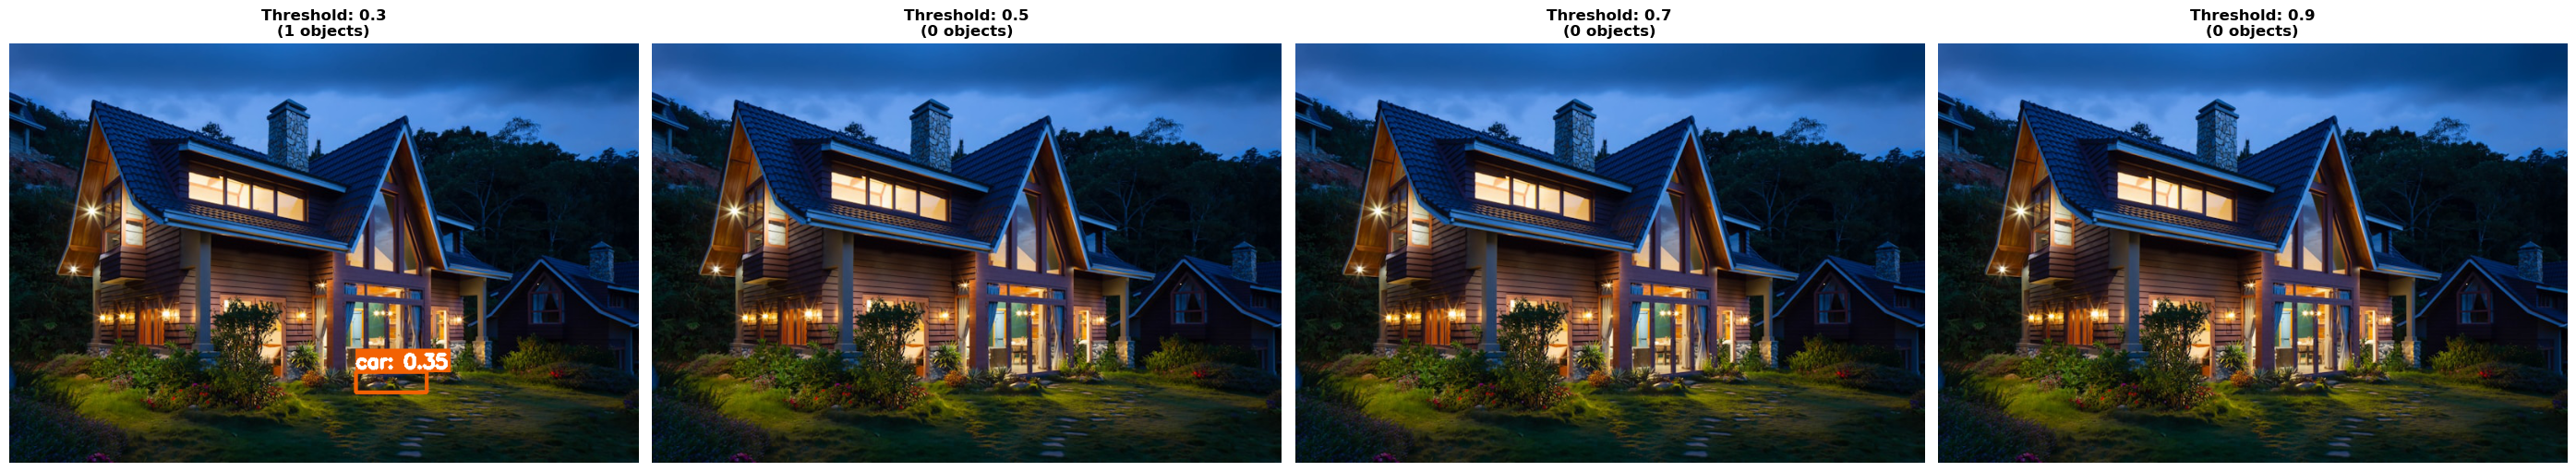


임계값별 탐지 객체 수:
----------------------------------------
Threshold 0.3:   1개
Threshold 0.5:   0개
Threshold 0.7:   0개
Threshold 0.9:   0개
----------------------------------------


In [35]:


"""
신뢰도 임계값에 따른 결과 비교
"""


def compare_thresholds(model, image, class_names, thresholds=[0.3, 0.5, 0.7, 0.9]):
    """
    다양한 신뢰도 임계값 비교


    Args:
        model: SSD 모델
        image: PIL Image
        class_names: 클래스 이름 리스트
        thresholds: 테스트할 임계값 리스트
    """
    # 전처리
    img_tensor, original = preprocess_image(image)


    # 한 번만 추론
    img_tensor = img_tensor.to(device)
    with torch.no_grad():
        predictions_full = model(img_tensor)[0]


    # 서브플롯 생성
    num_thresholds = len(thresholds)
    fig, axes = plt.subplots(1, num_thresholds, figsize=(7*num_thresholds, 7))


    if num_thresholds == 1:
        axes = [axes]


    for idx, threshold in enumerate(thresholds):
        # 임계값으로 필터링
        keep = predictions_full['scores'] > threshold
        filtered = {
            'boxes': predictions_full['boxes'][keep],
            'labels': predictions_full['labels'][keep],
            'scores': predictions_full['scores'][keep]
        }


        num_detections = len(filtered['boxes'])


        # 시각화
        result = visualize_predictions(original, filtered, class_names)


        axes[idx].imshow(result)
        axes[idx].set_title(
            f"Threshold: {threshold}\n({num_detections} objects)",
            fontsize=12,
            fontweight='bold'
        )
        axes[idx].axis('off')


    plt.tight_layout()
    plt.show()


    # 통계 출력
    print("\n임계값별 탐지 객체 수:")
    print("-" * 40)
    for threshold in thresholds:
        keep = predictions_full['scores'] > threshold
        count = keep.sum().item()
        print(f"Threshold {threshold:.1f}: {count:3d}개")
    print("-" * 40)




print("\n" + "="*60)
print("신뢰도 임계값 비교")
print("="*60)


# 테스트 이미지 준비
test_url = "https://images.unsplash.com/photo-1568605114967-8130f3a36994?w=800"
image = download_image(test_url)


if image is not None:
    compare_thresholds(
        model,
        image,
        class_names,
        thresholds=[0.3, 0.5, 0.7, 0.9]
    )






아래 셀을 실행하면 파일 업로드 창이 나타납니다.
이미지를 선택하여 업로드하세요!

이미지 크기: (1200, 900)
탐지된 객체 수 : 2
1. cat             | 신뢰도: 94.41%
2. laptop          | 신뢰도: 70.62%
------------------------------------------------------------


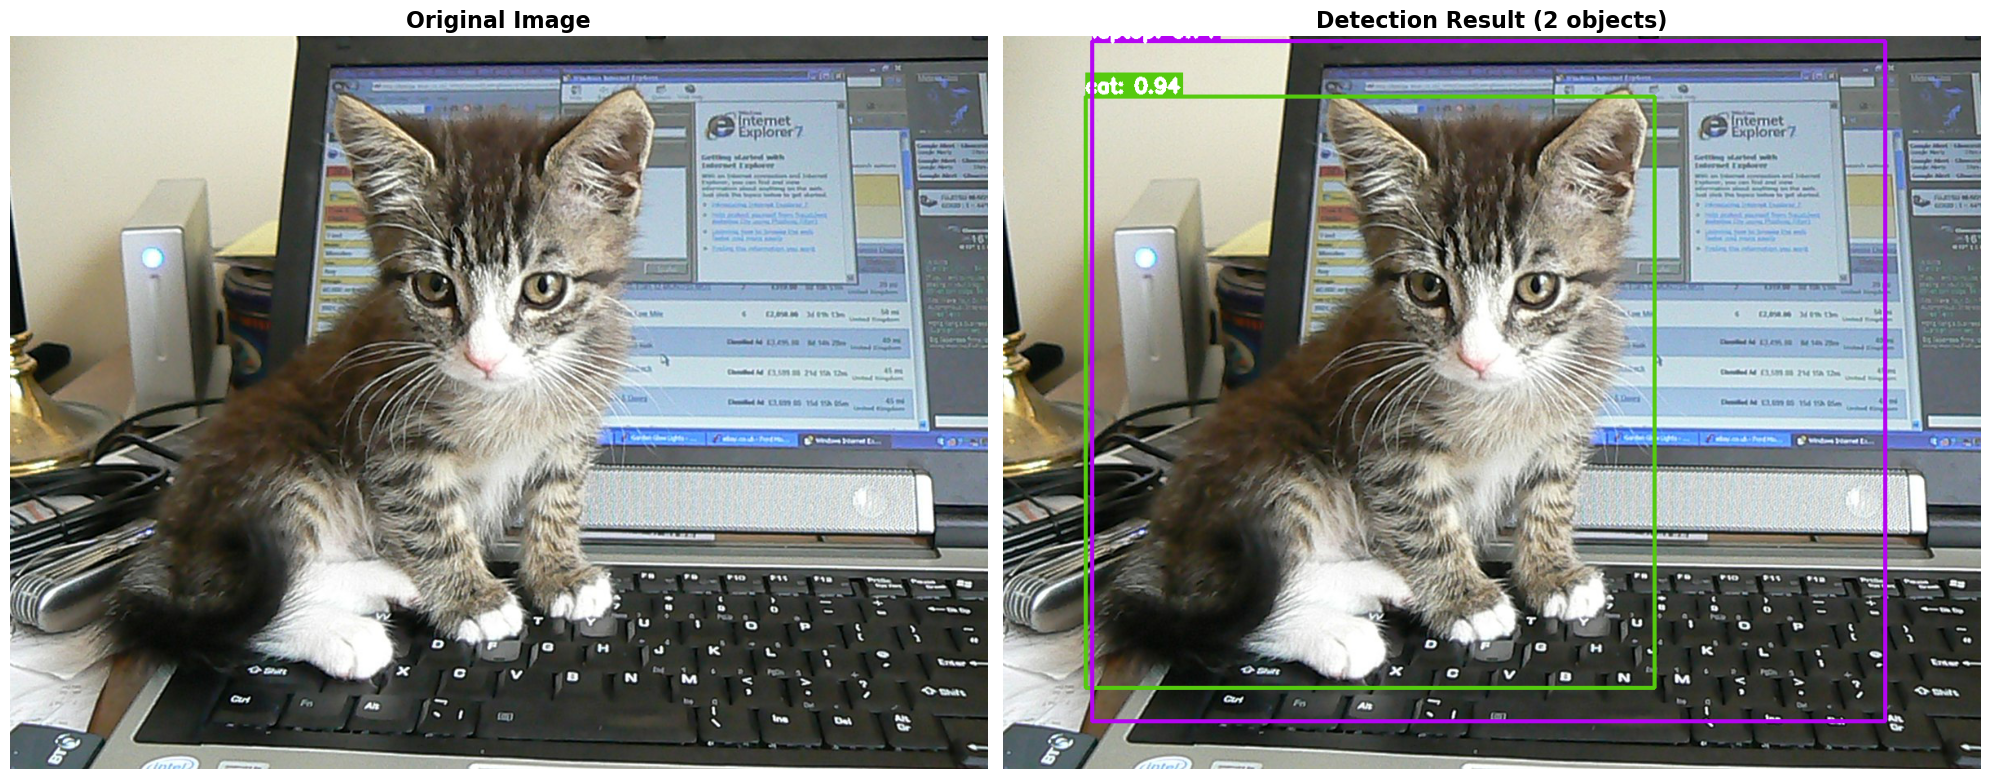

In [36]:
# Colab에서 파일 업로드 기능 사용
# from google.colab import files


def test_uploaded_image(model, class_names, path, confidence_threshold=0.5):


    # uploaded = files.upload()


    # if len(uploaded) == 0:
    #     print("업로드된 파일이 없습니다.")
    #     return


    # 업로드된 첫 번째 이미지 사용
    # filename = list(uploaded.keys())[0]
    # print(f"업로드된 파일: {filename}")


    # 이미지 로드
    # image = Image.open(filename).convert('RGB')
    image = Image.open(path)
    print(f"이미지 크기: {image.size}")


    # 전처리
    img_tensor, original = preprocess_image(image)


    # 탐지
    predictions = detect_objects(model, img_tensor, confidence_threshold)


    # 시각화
    result = visualize_predictions(original, predictions, class_names)


    # 결과 출력
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))


    axes[0].imshow(original)
    axes[0].set_title("Original Image", fontsize=16, fontweight='bold')
    axes[0].axis('off')


    axes[1].imshow(result)
    axes[1].set_title(f"Detection Result ({len(predictions['boxes'])} objects)",
                     fontsize=16, fontweight='bold')
    axes[1].axis('off')


    plt.tight_layout()
    plt.show()




print("\n" + "="*60)
print("="*60)
print("\n아래 셀을 실행하면 파일 업로드 창이 나타납니다.")
print("이미지를 선택하여 업로드하세요!\n")


# 실행
path = '/home/kim/Desktop/AI_cours/data/cat_on_a_laptop.jpg'
test_uploaded_image(model, class_names, path, confidence_threshold=0.5)


